In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os; os.makedirs("plots"); os.makedirs("models")

In [2]:
class NoiseScheduler:
    def __init__(self, T=1000, schedule="linear", beta_start=0.0001, beta_end=0.02):
        self.T = T
        if schedule == "linear":
            self.betas = torch.linspace(beta_start, beta_end, T)
            self.alphas = 1 - self.betas
            self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        elif schedule == "cosine":
            s = 0.008
            t = torch.arange(0, T+1)
            alpha_bars = torch.cos(((t/T + s) / (1 + s)) * torch.pi / 2) ** 2
            alpha_bars = alpha_bars / alpha_bars[0]
            self.betas = (1 - alpha_bars[1:] / alpha_bars[:-1]).clamp(0, 0.999)
            self.alphas = 1 - self.betas
            self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        
    def add_noise(self, x0, t, epsilon):
        # t is an integer or batch of integers
        device = x0.device
        alpha_bar_t = self.alpha_bars.to(t.device)[t]
        
        # reshape for broadcasting with image dimensions (B, C, H, W)
        while alpha_bar_t.dim() < x0.dim():
            alpha_bar_t = alpha_bar_t.unsqueeze(-1)
        
        xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * epsilon
        return xt

class TimeEmbedding(nn.Module):
    # PE(t, 2i) = sin(t / 10000^(2i/d))
    # PE(t, 2i+1) = cos(t / 10000^(2i/d))
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(in_features=dim, out_features=dim*2),
            nn.SiLU(),
            nn.Linear(in_features=dim*2, out_features=dim)
        )
    def forward(self, t):
        # t shape: (batch,)
        device = t.device
        half_dim = self.dim // 2
        i = torch.arange(0, half_dim, device=device) 
        div_term = 10000 ** (2 * i / self.dim)
        
        # t needs to be (batch, 1) to broadcast against div_term (half_dim,)
        t = t.unsqueeze(1).float()
        
        sins = torch.sin(t/div_term)
        coss = torch.cos(t/div_term)
        emb = torch.cat((sins, coss), dim=-1)
        return self.mlp(emb)  # shape: (batch, dim)

In [3]:
def get_groups(channels):
    for g in [32, 16, 8, 4, 2, 1]:
        if channels % g == 0:
            return g
    return 1

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, time_dim, num_groups=2):
        super().__init__()
        # block1: conv → groupnorm → silu
        self.block_1 = nn.Sequential(
            nn.GroupNorm(get_groups(in_channels), in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, 
                                  kernel_size=kernel_size, padding=1),
        )
        # block2: conv → groupnorm → silu
        self.block_2 = nn.Sequential(
            nn.GroupNorm(get_groups(out_channels), out_channels ),
            nn.SiLU(),
            nn.Conv2d(in_channels=out_channels, out_channels=out_channels, 
                                  kernel_size=kernel_size, padding=1),
        )
        # time_mlp: linear to project time embedding to out_channels
        self.mlp = nn.Linear(time_dim, out_channels)
        # residual_conv: 1x1 conv if in_channels != out_channels, else identity
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual_conv = nn.Identity()
        
    def forward(self, x, t):
        org_x = x
        # 1. pass x through block1
        x = self.block_1(x)
        # 2. project t embedding and add to output
        mapped_embeddings = self.mlp(t).unsqueeze(-1).unsqueeze(-1)    
        x = x+mapped_embeddings
        # 3. pass through block2
        x = self.block_2(x)
        # 4. add residual connection
        return self.residual_conv(org_x) + x

class SelfAttention(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(1, channels)
        self.attention = nn.MultiheadAttention(channels, num_heads, batch_first=True)
        
    def forward(self, x):
        B, C, H, W = x.shape
        # normalize
        x_norm = self.norm(x)
        # reshape to sequence: (B, H*W, C)
        x_flat = x_norm.reshape(B, C, H*W).transpose(1, 2)
        # self attention
        attn_out, _ = self.attention(x_flat, x_flat, x_flat)
        # reshape back: (B, C, H, W)
        attn_out = attn_out.transpose(1, 2).reshape(B, C, H, W)
        # residual connection
        return x + attn_out

class Unet(nn.Module):
    def __init__(self, in_channels, out_channel, kernel_size, time_dim, num_groups:int=2):
        super().__init__()
        # Encoder Part ResBlocks
        self.encoder_resblock_1 = ResBlock(in_channels, out_channel, kernel_size, time_dim, num_groups)
        self.encoder_resblock_2 = ResBlock(out_channel, out_channel*2, kernel_size, time_dim, num_groups)
        # Encoder Downsamplers
        self.downsampler1 = nn.MaxPool2d(2)
        self.downsampler2 = nn.MaxPool2d(2)

        # BottleNeck:
        self.bottleneck = ResBlock(out_channel*2, out_channel*2, kernel_size, time_dim, num_groups)
        self.attn_ = SelfAttention(channels=out_channel*2)
        # Decoder Resblocks
        self.decoder_resblock_1 = ResBlock(out_channel*4, out_channel, kernel_size, time_dim, num_groups)
        self.decoder_resblock_2 = ResBlock(out_channel*2, out_channel, kernel_size, time_dim, num_groups)
        # Decoder Upsamplers
        self.upsampler1 = nn.Upsample(scale_factor=2)
        self.upsampler2 = nn.Upsample(scale_factor=2)

        # Embedding layer
        self.embeddings = TimeEmbedding(dim=time_dim)
        # output layer
        self.output_layer = nn.Conv2d(out_channel, in_channels, kernel_size=1)

    def forward(self, x, t):
        # 1. time embedding
        t_emb = self.embeddings(t)
        # 2. encoder block 1 + save skip1
        ex1 = self.encoder_resblock_1(x, t_emb)
        # 3. downsample
        down_ex1 = self.downsampler1(ex1)
        # 4. encoder block 2 + save skip2
        ex2 = self.encoder_resblock_2(down_ex1, t_emb)
        # 5. downsample
        down_ex2 = self.downsampler2(ex2)

        # 6. bottleneck
        btnx = self.bottleneck(down_ex2, t_emb)
        btnx = self.attn_(btnx)

        # 7. upsample
        up_dx1 = self.upsampler1(btnx)
        # 8. concat skip2 + decoder block 1
        cat1 = torch.cat([up_dx1, ex2], dim=1)
        dx1 = self.decoder_resblock_1(cat1, t_emb) 
        # 9. upsample
        up_dx2 = self.upsampler2(dx1)
        # 10. concat skip1 + decoder block 2
        cat2 = torch.cat([up_dx2, ex1], dim=1)
        dx2 = self.decoder_resblock_2(cat2, t_emb)

        # 11. output conv
        out = self.output_layer(dx2)
        return out

In [4]:
def _sample(model, noise_scheduler, n_samples, device):
    model.eval()
    betas = noise_scheduler.betas
    alphas = noise_scheduler.alphas
    alpha_bars = noise_scheduler.alpha_bars
    with torch.no_grad():
        xt = torch.randn(n_samples, 1, 28, 28).to(device)   
        for t in range(999, 0, -1):
            t_batch = torch.tensor([t] * n_samples).to(device)
            pred_noise = model(xt, t_batch)
            z = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
            sigma_t = torch.sqrt(betas[t])
            x_prev = (1/torch.sqrt(alphas[t])) * (xt - (betas[t]/torch.sqrt(1 - alpha_bars[t])) * pred_noise) + sigma_t * z
            xt = x_prev
    return xt

def _plot(samples, filename:str):
    fig, axes = plt.subplots(1, 8, figsize=(16, 2))
    for i, ax in enumerate(axes):
        img = samples[i, 0].cpu().numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    plt.savefig(filename, dpi=150)
    plt.show()

In [25]:
def train(model, noise_scheduler, train_dl, val_dl, optimizer,
           epochs, device, lr_scheduler, n_samples:int=8, _sample:callable=_sample, model_name:str="ddpm"):
    print(f"Using: {device}")
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # training loop
        model.train()
        train_loss = 0
        for x0, _ in train_dl:
            x0 = x0.to(device)
            t = torch.randint(0, 1000, size=(x0.shape[0],)).to(device)
            true_noise = torch.randn_like(x0)
            noisy_x0 = noise_scheduler.add_noise(x0, t, true_noise)
            pred_noise = model(noisy_x0, t)
            _mse = F.mse_loss(pred_noise, true_noise)
            _mse.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            lr_scheduler.step()
        
            optimizer.zero_grad()
            train_loss += _mse.item()

        
        # validation loop
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x0, _ in val_dl:
                x0 = x0.to(device)
                t = torch.randint(0, 1000, size=(x0.shape[0],)).to(device)
                true_noise = torch.randn_like(x0)
                noisy_x0 = noise_scheduler.add_noise(x0, t, true_noise)
                pred_noise = model(noisy_x0, t)
                _mse = F.mse_loss(pred_noise, true_noise)
                val_loss += _mse.item()

        if epoch % 10 == 0:
            samples = _sample(model, noise_scheduler, n_samples=n_samples, device=device)
            filesname = "plots/" + model_name + f"samples{epoch}.png"
            _plot(samples, filesname)
        
        # checkpointing
        avg_val = val_loss / len(val_dl)
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), f'models/{model_name}.pth')
            print(f"Saved best model at epoch {epoch}")
        
        print(f"Epoch {epoch} | Train: {train_loss/len(train_dl):.4f} | Val: {avg_val:.4f}")

In [26]:
batch_size=64
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))  # normalize to [-1, 1]
])

dataset = datasets.FashionMNIST(root='../data', train=True, download=True, transform=transform)
dl = DataLoader(dataset, batch_size=batch_size, shuffle=True)

val_dataset = datasets.FashionMNIST(root='../data', train=False, download=True, transform=transform)
val_dl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [27]:
lr = 2e-4
epochs = 70
steps_per_epoch = len(dl) 

Using: cuda


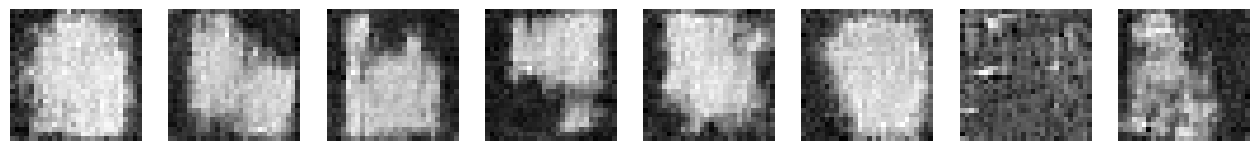

Saved best model at epoch 0
Epoch 0 | Train: 0.1604 | Val: 0.0878
Saved best model at epoch 1
Epoch 1 | Train: 0.0761 | Val: 0.0691
Saved best model at epoch 2
Epoch 2 | Train: 0.0645 | Val: 0.0623
Saved best model at epoch 3
Epoch 3 | Train: 0.0583 | Val: 0.0562
Saved best model at epoch 4
Epoch 4 | Train: 0.0548 | Val: 0.0529
Epoch 5 | Train: 0.0526 | Val: 0.0532
Saved best model at epoch 6
Epoch 6 | Train: 0.0499 | Val: 0.0519
Saved best model at epoch 7
Epoch 7 | Train: 0.0482 | Val: 0.0472
Epoch 8 | Train: 0.0479 | Val: 0.0484
Saved best model at epoch 9
Epoch 9 | Train: 0.0460 | Val: 0.0443


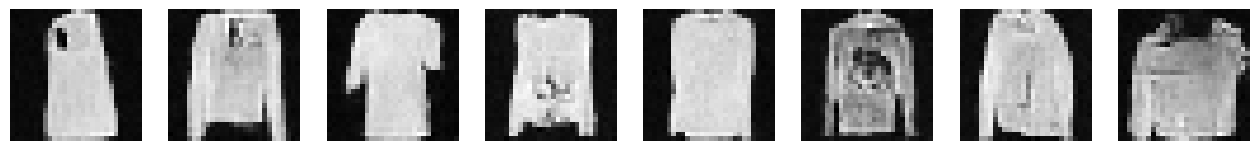

Epoch 10 | Train: 0.0459 | Val: 0.0456
Epoch 11 | Train: 0.0449 | Val: 0.0468
Saved best model at epoch 12
Epoch 12 | Train: 0.0437 | Val: 0.0433
Epoch 13 | Train: 0.0442 | Val: 0.0472
Saved best model at epoch 14
Epoch 14 | Train: 0.0435 | Val: 0.0425
Saved best model at epoch 15
Epoch 15 | Train: 0.0429 | Val: 0.0414
Epoch 16 | Train: 0.0420 | Val: 0.0447
Saved best model at epoch 17
Epoch 17 | Train: 0.0426 | Val: 0.0409
Epoch 18 | Train: 0.0418 | Val: 0.0424
Epoch 19 | Train: 0.0413 | Val: 0.0416


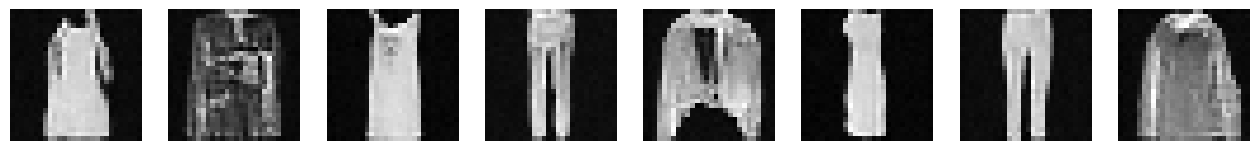

Epoch 20 | Train: 0.0416 | Val: 0.0418
Epoch 21 | Train: 0.0405 | Val: 0.0418
Epoch 22 | Train: 0.0406 | Val: 0.0413
Saved best model at epoch 23
Epoch 23 | Train: 0.0407 | Val: 0.0404
Saved best model at epoch 24
Epoch 24 | Train: 0.0403 | Val: 0.0403
Saved best model at epoch 25
Epoch 25 | Train: 0.0396 | Val: 0.0401
Epoch 26 | Train: 0.0397 | Val: 0.0403
Epoch 27 | Train: 0.0394 | Val: 0.0403
Epoch 28 | Train: 0.0391 | Val: 0.0407
Saved best model at epoch 29
Epoch 29 | Train: 0.0392 | Val: 0.0389


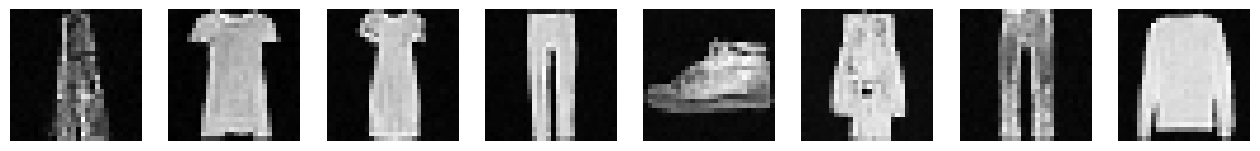

Saved best model at epoch 30
Epoch 30 | Train: 0.0386 | Val: 0.0373
Epoch 31 | Train: 0.0389 | Val: 0.0405
Epoch 32 | Train: 0.0384 | Val: 0.0397
Epoch 33 | Train: 0.0388 | Val: 0.0386
Epoch 34 | Train: 0.0383 | Val: 0.0378
Epoch 35 | Train: 0.0385 | Val: 0.0394
Epoch 36 | Train: 0.0383 | Val: 0.0374
Epoch 37 | Train: 0.0384 | Val: 0.0381
Epoch 38 | Train: 0.0383 | Val: 0.0380
Epoch 39 | Train: 0.0380 | Val: 0.0380


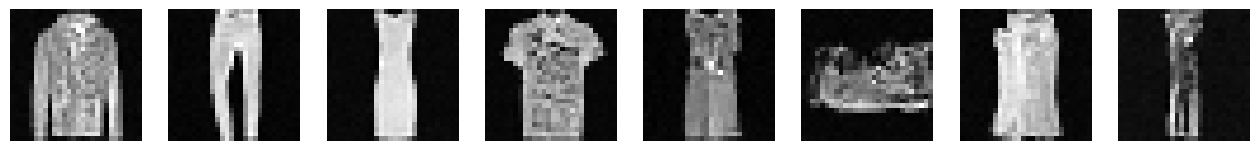

Saved best model at epoch 40
Epoch 40 | Train: 0.0377 | Val: 0.0370
Epoch 41 | Train: 0.0376 | Val: 0.0376
Epoch 42 | Train: 0.0378 | Val: 0.0370
Epoch 43 | Train: 0.0377 | Val: 0.0381
Epoch 44 | Train: 0.0364 | Val: 0.0371
Epoch 45 | Train: 0.0370 | Val: 0.0381
Epoch 46 | Train: 0.0369 | Val: 0.0382
Saved best model at epoch 47
Epoch 47 | Train: 0.0372 | Val: 0.0368
Epoch 48 | Train: 0.0375 | Val: 0.0393
Epoch 49 | Train: 0.0372 | Val: 0.0381


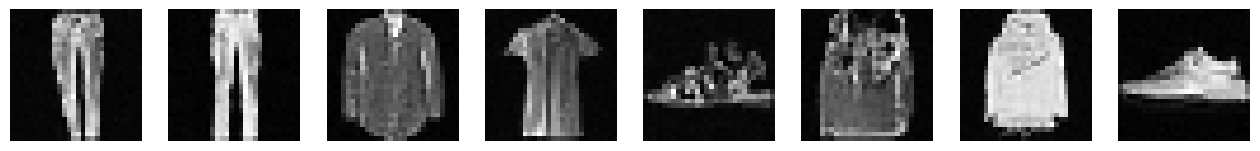

Epoch 50 | Train: 0.0370 | Val: 0.0394
Saved best model at epoch 51
Epoch 51 | Train: 0.0370 | Val: 0.0365
Epoch 52 | Train: 0.0364 | Val: 0.0369
Epoch 53 | Train: 0.0370 | Val: 0.0375
Saved best model at epoch 54
Epoch 54 | Train: 0.0360 | Val: 0.0356
Epoch 55 | Train: 0.0368 | Val: 0.0370
Epoch 56 | Train: 0.0365 | Val: 0.0370
Epoch 57 | Train: 0.0366 | Val: 0.0365
Epoch 58 | Train: 0.0360 | Val: 0.0370
Epoch 59 | Train: 0.0364 | Val: 0.0362


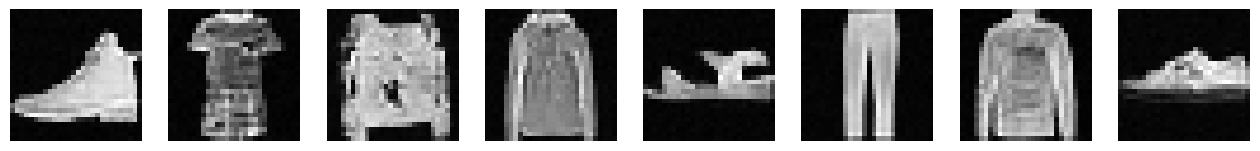

Epoch 60 | Train: 0.0362 | Val: 0.0366
Epoch 61 | Train: 0.0365 | Val: 0.0368
Epoch 62 | Train: 0.0361 | Val: 0.0367
Epoch 63 | Train: 0.0364 | Val: 0.0362
Epoch 64 | Train: 0.0364 | Val: 0.0378
Epoch 65 | Train: 0.0356 | Val: 0.0365
Epoch 66 | Train: 0.0361 | Val: 0.0362
Epoch 67 | Train: 0.0357 | Val: 0.0377
Epoch 68 | Train: 0.0360 | Val: 0.0374
Epoch 69 | Train: 0.0361 | Val: 0.0369


In [28]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Unet(in_channels=1, out_channel=64, kernel_size=3, time_dim=128).to(device)
noise_scheduler = NoiseScheduler()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=steps_per_epoch, epochs=epochs)

train(model, noise_scheduler, dl, val_dl, optimizer=optimizer, epochs=epochs, device=device, lr_scheduler=scheduler,
      _sample=_sample, model_name="ddpm_fashionmnist")

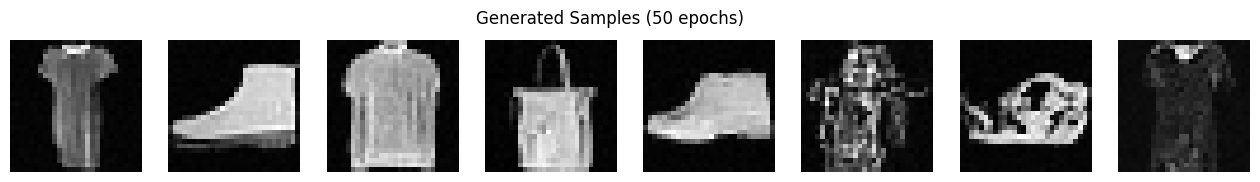

In [29]:
def sample(model, noise_scheduler, n_samples, device):
    model.eval()
    betas = noise_scheduler.betas
    alphas = noise_scheduler.alphas
    alpha_bars = noise_scheduler.alpha_bars
    with torch.no_grad():
        xt = torch.randn(n_samples, 1, 28, 28).to(device)   
        for t in range(999, 0, -1):
            t_batch = torch.tensor([t] * n_samples).to(device)
            pred_noise = model(xt, t_batch)
            z = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
            sigma_t = torch.sqrt(betas[t])
            x_prev = (1/torch.sqrt(alphas[t])) * (xt - (betas[t]/torch.sqrt(1 - alpha_bars[t])) * pred_noise) + sigma_t * z
            xt = x_prev
    return xt

# visualize
samples = sample(model, noise_scheduler, n_samples=8, device=device)
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = samples[i, 0].cpu().numpy()
    ax.imshow(img, cmap='gray')
    ax.axis('off')
plt.suptitle('Generated Samples (50 epochs)')
plt.savefig('samples_5epochs.png', dpi=150)
plt.show()

In [25]:
torch.save(model.state_dict(), '../models/ddpm_fashionmnist_50epochs.pth')

#### CIFAR - 10

In [30]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # normalize to [-1, 1]
])

dataset = datasets.CIFAR10(root='../data', train=True, download=True, transform=transform)
dl = DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 170M/170M [20:28<00:00, 139kB/s] 


In [35]:
def _sample_cifar10(model, noise_scheduler, n_samples, device):
    model.eval()
    betas = noise_scheduler.betas.to(device)
    alphas = noise_scheduler.alphas.to(device)
    alpha_bars = noise_scheduler.alpha_bars.to(device)
    with torch.no_grad():
        xt = torch.randn(n_samples, 3, 32, 32).to(device)   
        for t in range(999, -1, -1):
            t_batch = torch.tensor([t] * n_samples).to(device)
            pred_noise = model(xt, t_batch)
            pred_nosie = pred_noise.clamp(-1, 1)
            z = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
            sigma_t = torch.sqrt(betas[t])
            denom  = torch.sqrt(alphas[t]) + 1e-8
            x_prev = (1/denom) * (xt - (betas[t]/torch.sqrt(1 - alpha_bars[t] + 1e-8)) * pred_noise) + sigma_t * z
            xt = x_prev.clamp(-2, 2)
    return xt

def _plot(samples, filename):
    fig, axes = plt.subplots(1, 8, figsize=(16, 2))
    for i, ax in enumerate(axes):
        img = samples[i].cpu().numpy()  # (3, 32, 32)
        img = img.transpose(1, 2, 0)   # (32, 32, 3)
        img = (img + 1) / 2            # denormalize from [-1,1] to [0,1]
        img = img.clip(0, 1)
        ax.imshow(img)
        ax.axis('off')
    plt.savefig(filename, dpi=150)
    plt.show()

In [36]:
val_dataset = datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)
val_dl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [37]:
lr = 2e-4
epochs = 80
steps_per_epoch = len(dl) 

no of model parameters: sum([p.numel() for p in model.parameters()])
Using: cuda


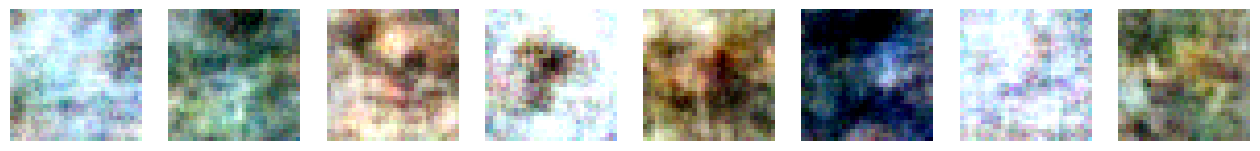

Saved best model at epoch 0
Epoch 0 | Train: 0.1511 | Val: 0.0657
Saved best model at epoch 1
Epoch 1 | Train: 0.0558 | Val: 0.0518
Saved best model at epoch 2
Epoch 2 | Train: 0.0477 | Val: 0.0459
Saved best model at epoch 3
Epoch 3 | Train: 0.0437 | Val: 0.0439
Saved best model at epoch 4
Epoch 4 | Train: 0.0427 | Val: 0.0416
Saved best model at epoch 5
Epoch 5 | Train: 0.0404 | Val: 0.0396
Saved best model at epoch 6
Epoch 6 | Train: 0.0393 | Val: 0.0391
Saved best model at epoch 7
Epoch 7 | Train: 0.0383 | Val: 0.0383
Epoch 8 | Train: 0.0380 | Val: 0.0389
Epoch 9 | Train: 0.0374 | Val: 0.0383


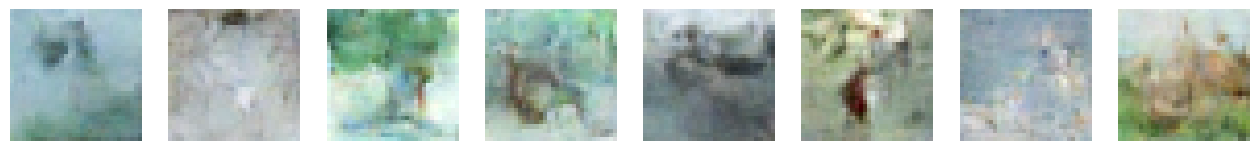

Saved best model at epoch 10
Epoch 10 | Train: 0.0375 | Val: 0.0382
Saved best model at epoch 11
Epoch 11 | Train: 0.0365 | Val: 0.0354
Epoch 12 | Train: 0.0359 | Val: 0.0379
Epoch 13 | Train: 0.0362 | Val: 0.0362
Epoch 14 | Train: 0.0355 | Val: 0.0354
Epoch 15 | Train: 0.0352 | Val: 0.0355
Saved best model at epoch 16
Epoch 16 | Train: 0.0346 | Val: 0.0349
Epoch 17 | Train: 0.0355 | Val: 0.0359
Saved best model at epoch 18
Epoch 18 | Train: 0.0347 | Val: 0.0338
Epoch 19 | Train: 0.0351 | Val: 0.0354


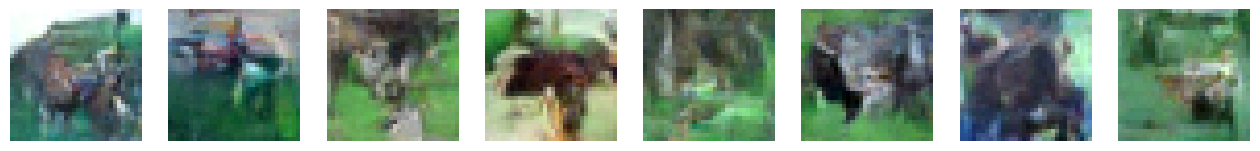

Epoch 20 | Train: 0.0346 | Val: 0.0349
Epoch 21 | Train: 0.0340 | Val: 0.0339
Epoch 22 | Train: 0.0340 | Val: 0.0357
Epoch 23 | Train: 0.0337 | Val: 0.0341
Saved best model at epoch 24
Epoch 24 | Train: 0.0340 | Val: 0.0332
Epoch 25 | Train: 0.0340 | Val: 0.0345
Epoch 26 | Train: 0.0336 | Val: 0.0336
Saved best model at epoch 27
Epoch 27 | Train: 0.0337 | Val: 0.0329
Epoch 28 | Train: 0.0336 | Val: 0.0334
Epoch 29 | Train: 0.0331 | Val: 0.0336


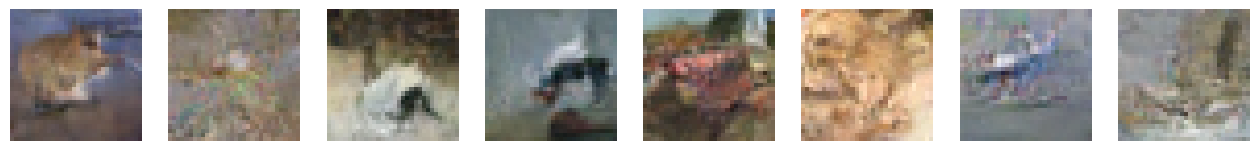

Saved best model at epoch 30
Epoch 30 | Train: 0.0330 | Val: 0.0328
Epoch 31 | Train: 0.0331 | Val: 0.0336
Epoch 32 | Train: 0.0325 | Val: 0.0333
Epoch 33 | Train: 0.0322 | Val: 0.0332
Saved best model at epoch 34
Epoch 34 | Train: 0.0327 | Val: 0.0326
Saved best model at epoch 35
Epoch 35 | Train: 0.0322 | Val: 0.0323
Saved best model at epoch 36
Epoch 36 | Train: 0.0327 | Val: 0.0321
Epoch 37 | Train: 0.0320 | Val: 0.0322
Epoch 38 | Train: 0.0325 | Val: 0.0324
Saved best model at epoch 39
Epoch 39 | Train: 0.0325 | Val: 0.0320


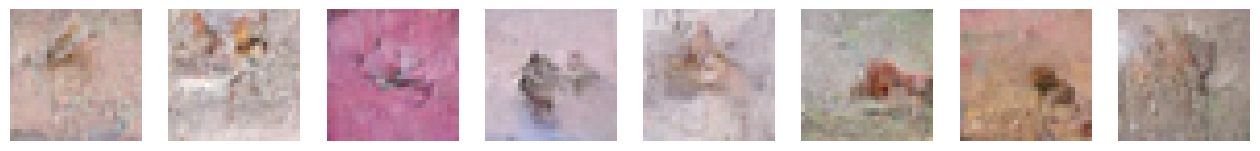

Saved best model at epoch 40
Epoch 40 | Train: 0.0318 | Val: 0.0317
Epoch 41 | Train: 0.0324 | Val: 0.0333
Saved best model at epoch 42
Epoch 42 | Train: 0.0326 | Val: 0.0312
Epoch 43 | Train: 0.0322 | Val: 0.0333
Epoch 44 | Train: 0.0330 | Val: 0.0318
Epoch 45 | Train: 0.0325 | Val: 0.0318
Epoch 46 | Train: 0.0316 | Val: 0.0324
Epoch 47 | Train: 0.0315 | Val: 0.0323
Epoch 48 | Train: 0.0313 | Val: 0.0318
Epoch 49 | Train: 0.0315 | Val: 0.0318


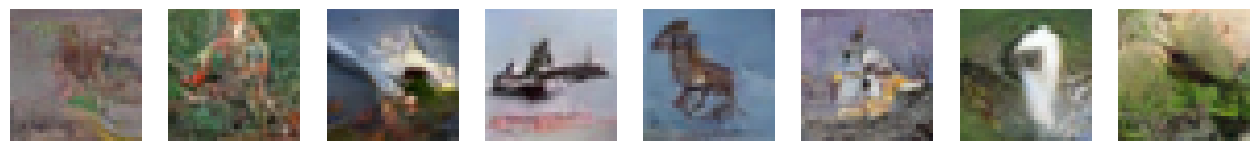

Epoch 50 | Train: 0.0320 | Val: 0.0316
Epoch 51 | Train: 0.0315 | Val: 0.0324
Epoch 52 | Train: 0.0319 | Val: 0.0326
Epoch 53 | Train: 0.0319 | Val: 0.0322
Epoch 54 | Train: 0.0316 | Val: 0.0316
Epoch 55 | Train: 0.0318 | Val: 0.0314
Epoch 56 | Train: 0.0319 | Val: 0.0327
Epoch 57 | Train: 0.0316 | Val: 0.0320
Epoch 58 | Train: 0.0317 | Val: 0.0314
Epoch 59 | Train: 0.0317 | Val: 0.0319


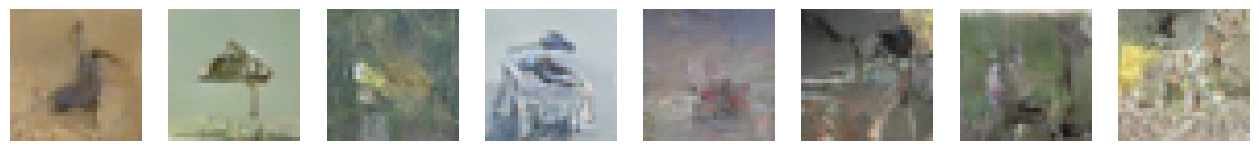

Epoch 60 | Train: 0.0315 | Val: 0.0312
Saved best model at epoch 61
Epoch 61 | Train: 0.0313 | Val: 0.0311
Epoch 62 | Train: 0.0315 | Val: 0.0315
Saved best model at epoch 63
Epoch 63 | Train: 0.0313 | Val: 0.0307
Epoch 64 | Train: 0.0312 | Val: 0.0312
Epoch 65 | Train: 0.0310 | Val: 0.0315
Epoch 66 | Train: 0.0312 | Val: 0.0308
Epoch 67 | Train: 0.0311 | Val: 0.0319
Epoch 68 | Train: 0.0313 | Val: 0.0307
Epoch 69 | Train: 0.0310 | Val: 0.0313


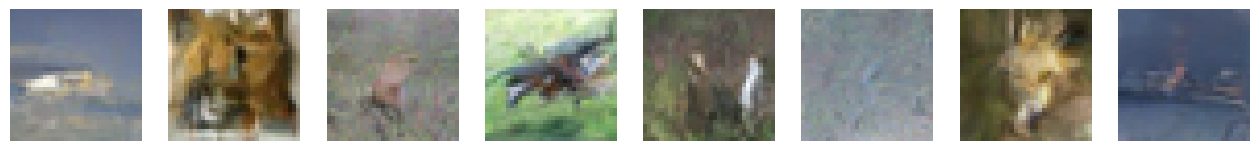

Saved best model at epoch 70
Epoch 70 | Train: 0.0309 | Val: 0.0306
Epoch 71 | Train: 0.0311 | Val: 0.0309
Saved best model at epoch 72
Epoch 72 | Train: 0.0309 | Val: 0.0306
Epoch 73 | Train: 0.0310 | Val: 0.0316
Epoch 74 | Train: 0.0307 | Val: 0.0314
Epoch 75 | Train: 0.0310 | Val: 0.0308
Epoch 76 | Train: 0.0313 | Val: 0.0310
Epoch 77 | Train: 0.0319 | Val: 0.0315
Epoch 78 | Train: 0.0308 | Val: 0.0320
Epoch 79 | Train: 0.0313 | Val: 0.0314


In [38]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Unet(in_channels=3, out_channel=128, kernel_size=3, time_dim=128).to(device)
noise_scheduler = NoiseScheduler()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
print(f"no of model parameters: sum([p.numel() for p in model.parameters()])")
lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, epochs=epochs,
                                                   steps_per_epoch=steps_per_epoch)

train(model, noise_scheduler, dl, val_dl, optimizer, epochs, device, lr_scheduler=lr_scheduler, 
     _sample=_sample_cifar10, model_name="ddpm_cifar10")

In [10]:
device = "cuda"
model = Unet(in_channels=3, out_channel=128, kernel_size=3, time_dim=128).to(device)
model.load_state_dict(torch.load('models/ddpm_cifar10.pth', map_location=device))
model.eval()

C:\Users\praty\AppData\Local\Temp\ipykernel_2976\2436746234.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../models/ddpm_cifar10_best

Unet(
  (encoder_resblock_1): ResBlock(
    (block_1): Sequential(
      (0): GroupNorm(1, 3, eps=1e-05, affine=True)
      (1): SiLU()
      (2): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (block_2): Sequential(
      (0): GroupNorm(32, 128, eps=1e-05, affine=True)
      (1): SiLU()
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (mlp): Linear(in_features=128, out_features=128, bias=True)
    (residual_conv): Conv2d(3, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (encoder_resblock_2): ResBlock(
    (block_1): Sequential(
      (0): GroupNorm(32, 128, eps=1e-05, affine=True)
      (1): SiLU()
      (2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (block_2): Sequential(
      (0): GroupNorm(32, 256, eps=1e-05, affine=True)
      (1): SiLU()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (mlp): Linear(in_features=128, out_features=256, bia

tensor(-0.9439, device='cuda:0') tensor(0.9830, device='cuda:0') tensor(-0.0022, device='cuda:0')


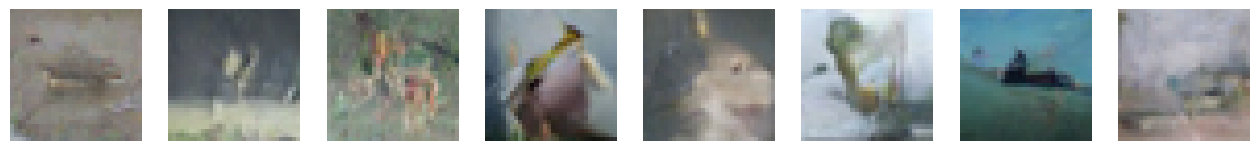

In [39]:
# visualize
samples = _sample_cifar10(model, noise_scheduler, n_samples=8, device=device)
print(samples.min(), samples.max(), samples.mean())
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = samples[i].cpu().numpy()  # (3, 32, 32)
    img = img.transpose(1, 2, 0)   # (32, 32, 3)
    img = (img + 1) / 2            # denormalize from [-1,1] to [0,1]
    img = img.clip(0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.savefig('samples_cifar.png', dpi=150)
plt.show()

In [14]:
sum([p.numel() for p in model.parameters()])

3978505